# Notebook zur Kombination der Pitch-Kalibrierung mit den Tracking-Ergebnissen

### Imports

In [2]:
from pathlib import Path
import subprocess
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Konfiguration

### Alle 30 Sekunden frame extrahieren und speichern

### Mapping 
Im `data/manser/soccernet/calibration-2023/train`-Datensatz wurden 5 .jpg, .json Paare gefunden, die in unser 5 Minuten Tracking Video reinfallen.

16413 10:31 -> 775  
16414 12:31 -> 3775  
16415 12:51 -> 4275  
16416 13:43 -> 5575  
16417 14:05 -> 6125  

In [8]:
FRAME_TO_CALIB_ID = {
    775: "16413",
    3775: "16414",
    4275: "16415",
    5575: "16416",
    6125: "16417",
}

In [7]:
TRACKING_OUTPUT_DIR = Path("/data/manser/tracking_outputs/modric_v2_yolo26n_malaga_clip_5min_conf055")
TRACKING_PARQUET_PATH = TRACKING_OUTPUT_DIR / "tracking_results.parquet"
TRACKING_CSV_PATH = TRACKING_OUTPUT_DIR / "tracking_results.csv"

# Calibration-Daten
CALIBRATION_BASE_PATH = Path("/data/manser/soccernet/calibration-2023/train")

# Output für Pitch-Mapping
OUTPUT_DIR = Path("data/manser/processed/modric_v2_pitch_tracking/pitch_mapping")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PITCH_CSV_PATH = OUTPUT_DIR / "tracking_pitch_coordinates.csv"
PITCH_PARQUET_PATH = OUTPUT_DIR / "tracking_pitch_coordinates.parquet"
PITCH_META_PATH = OUTPUT_DIR / "tracking_pitch_metadata.json"

# Spielfeldgroesse in Metern
PITCH_LENGTH_M = 105.0
PITCH_WIDTH_M = 68.0

# Visualisierung
PITCH_SCALE = 10  # für Plot-Visualisierung in Pixel pro Meter


### Trackingdaten laden

In [9]:
def load_tracking_results() -> pd.DataFrame:
    if TRACKING_PARQUET_PATH.exists():
        print(f"Lade Tracking-Parquet: {TRACKING_PARQUET_PATH}")
        return pd.read_parquet(TRACKING_PARQUET_PATH)

    if TRACKING_CSV_PATH.exists():
        print(f"Lade Tracking-CSV: {TRACKING_CSV_PATH}")
        return pd.read_csv(TRACKING_CSV_PATH)

    raise FileNotFoundError("Keine Tracking-Datei gefunden.")


df = load_tracking_results()
print(df.head())
print(f"Anzahl Zeilen: {len(df)}")

Lade Tracking-CSV: /data/manser/tracking_outputs/modric_v2_yolo26n_malaga_clip_5min_conf055/tracking_results.csv
   frame_idx  video_time_sec  track_id  class_id class_name  confidence  x1  \
0          0            0.00       NaN       NaN        NaN         NaN NaN   
1          1            0.04       NaN       NaN        NaN         NaN NaN   
2          2            0.08       NaN       NaN        NaN         NaN NaN   
3          3            0.12       NaN       NaN        NaN         NaN NaN   
4          4            0.16       NaN       NaN        NaN         NaN NaN   

   y1  x2  y2  width  height  cx  cy  foot_x  foot_y  orig_w  orig_h  \
0 NaN NaN NaN    NaN     NaN NaN NaN     NaN     NaN    1280     720   
1 NaN NaN NaN    NaN     NaN NaN NaN     NaN     NaN    1280     720   
2 NaN NaN NaN    NaN     NaN NaN NaN     NaN     NaN    1280     720   
3 NaN NaN NaN    NaN     NaN NaN NaN     NaN     NaN    1280     720   
4 NaN NaN NaN    NaN     NaN NaN NaN     NaN     NaN

### SoccerPitch + Kalibrierungsfunktion

In [10]:
# ==================================================
# SoccerPitch - planare Version fuer Pitch-Kalibrierung
# Koordinatensystem:
# x: links -> rechts
# y: oben -> unten
# Ursprung: linke obere Ecke = (0, 0)
# ==================================================
class SoccerPitch:
    GOAL_LINE_TO_PENALTY_MARK = 11.0
    PENALTY_AREA_WIDTH = 40.32
    PENALTY_AREA_LENGTH = 16.5
    GOAL_AREA_WIDTH = 18.32
    GOAL_AREA_LENGTH = 5.5
    CENTER_CIRCLE_RADIUS = 9.15
    GOAL_HEIGHT = 2.44
    GOAL_LENGTH = 7.32

    PLANAR_LINE_CLASSES = [
        "Big rect. left bottom",
        "Big rect. left main",
        "Big rect. left top",
        "Big rect. right bottom",
        "Big rect. right main",
        "Big rect. right top",
        "Middle line",
        "Side line bottom",
        "Side line left",
        "Side line right",
        "Side line top",
        "Small rect. left bottom",
        "Small rect. left main",
        "Small rect. left top",
        "Small rect. right bottom",
        "Small rect. right main",
        "Small rect. right top",
    ]

    ANCHOR_LINES = {
        "Side line left",
        "Side line right",
        "Side line top",
        "Side line bottom",
        "Middle line",
    }

    def __init__(self, pitch_length=105.0, pitch_width=68.0):
        self.PITCH_LENGTH = pitch_length
        self.PITCH_WIDTH = pitch_width

        self.point_dict = {
            "TL_PITCH_CORNER": np.array([0.0, 0.0, 0.0]),
            "BL_PITCH_CORNER": np.array([0.0, pitch_width, 0.0]),
            "TR_PITCH_CORNER": np.array([pitch_length, 0.0, 0.0]),
            "BR_PITCH_CORNER": np.array([pitch_length, pitch_width, 0.0]),

            "T_MIDDLE": np.array([pitch_length / 2.0, 0.0, 0.0]),
            "B_MIDDLE": np.array([pitch_length / 2.0, pitch_width, 0.0]),

            # Linker Strafraum
            "L_PENALTY_AREA_TL_CORNER": np.array([0.0, (pitch_width - self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "L_PENALTY_AREA_TR_CORNER": np.array([self.PENALTY_AREA_LENGTH, (pitch_width - self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "L_PENALTY_AREA_BL_CORNER": np.array([0.0, (pitch_width + self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "L_PENALTY_AREA_BR_CORNER": np.array([self.PENALTY_AREA_LENGTH, (pitch_width + self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),

            # Rechter Strafraum
            "R_PENALTY_AREA_TL_CORNER": np.array([pitch_length - self.PENALTY_AREA_LENGTH, (pitch_width - self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "R_PENALTY_AREA_TR_CORNER": np.array([pitch_length, (pitch_width - self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "R_PENALTY_AREA_BL_CORNER": np.array([pitch_length - self.PENALTY_AREA_LENGTH, (pitch_width + self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),
            "R_PENALTY_AREA_BR_CORNER": np.array([pitch_length, (pitch_width + self.PENALTY_AREA_WIDTH) / 2.0, 0.0]),

            # Linker Fuenfmeterraum
            "L_GOAL_AREA_TL_CORNER": np.array([0.0, (pitch_width - self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "L_GOAL_AREA_TR_CORNER": np.array([self.GOAL_AREA_LENGTH, (pitch_width - self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "L_GOAL_AREA_BL_CORNER": np.array([0.0, (pitch_width + self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "L_GOAL_AREA_BR_CORNER": np.array([self.GOAL_AREA_LENGTH, (pitch_width + self.GOAL_AREA_WIDTH) / 2.0, 0.0]),

            # Rechter Fuenfmeterraum
            "R_GOAL_AREA_TL_CORNER": np.array([pitch_length - self.GOAL_AREA_LENGTH, (pitch_width - self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "R_GOAL_AREA_TR_CORNER": np.array([pitch_length, (pitch_width - self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "R_GOAL_AREA_BL_CORNER": np.array([pitch_length - self.GOAL_AREA_LENGTH, (pitch_width + self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
            "R_GOAL_AREA_BR_CORNER": np.array([pitch_length, (pitch_width + self.GOAL_AREA_WIDTH) / 2.0, 0.0]),
        }

        self.line_extremities = {
            # Feld
            "Side line top": (
                self.point_dict["TL_PITCH_CORNER"],
                self.point_dict["TR_PITCH_CORNER"],
            ),
            "Side line bottom": (
                self.point_dict["BL_PITCH_CORNER"],
                self.point_dict["BR_PITCH_CORNER"],
            ),
            "Side line left": (
                self.point_dict["TL_PITCH_CORNER"],
                self.point_dict["BL_PITCH_CORNER"],
            ),
            "Side line right": (
                self.point_dict["TR_PITCH_CORNER"],
                self.point_dict["BR_PITCH_CORNER"],
            ),
            "Middle line": (
                self.point_dict["T_MIDDLE"],
                self.point_dict["B_MIDDLE"],
            ),

            # Linker Strafraum
            "Big rect. left top": (
                self.point_dict["L_PENALTY_AREA_TL_CORNER"],
                self.point_dict["L_PENALTY_AREA_TR_CORNER"],
            ),
            "Big rect. left bottom": (
                self.point_dict["L_PENALTY_AREA_BL_CORNER"],
                self.point_dict["L_PENALTY_AREA_BR_CORNER"],
            ),
            "Big rect. left main": (
                self.point_dict["L_PENALTY_AREA_TR_CORNER"],
                self.point_dict["L_PENALTY_AREA_BR_CORNER"],
            ),

            # Rechter Strafraum
            "Big rect. right top": (
                self.point_dict["R_PENALTY_AREA_TL_CORNER"],
                self.point_dict["R_PENALTY_AREA_TR_CORNER"],
            ),
            "Big rect. right bottom": (
                self.point_dict["R_PENALTY_AREA_BL_CORNER"],
                self.point_dict["R_PENALTY_AREA_BR_CORNER"],
            ),
            "Big rect. right main": (
                self.point_dict["R_PENALTY_AREA_TL_CORNER"],
                self.point_dict["R_PENALTY_AREA_BL_CORNER"],
            ),

            # Linker Fuenfmeterraum
            "Small rect. left top": (
                self.point_dict["L_GOAL_AREA_TL_CORNER"],
                self.point_dict["L_GOAL_AREA_TR_CORNER"],
            ),
            "Small rect. left bottom": (
                self.point_dict["L_GOAL_AREA_BL_CORNER"],
                self.point_dict["L_GOAL_AREA_BR_CORNER"],
            ),
            "Small rect. left main": (
                self.point_dict["L_GOAL_AREA_TR_CORNER"],
                self.point_dict["L_GOAL_AREA_BR_CORNER"],
            ),

            # Rechter Fuenfmeterraum
            "Small rect. right top": (
                self.point_dict["R_GOAL_AREA_TL_CORNER"],
                self.point_dict["R_GOAL_AREA_TR_CORNER"],
            ),
            "Small rect. right bottom": (
                self.point_dict["R_GOAL_AREA_BL_CORNER"],
                self.point_dict["R_GOAL_AREA_BR_CORNER"],
            ),
            "Small rect. right main": (
                self.point_dict["R_GOAL_AREA_TL_CORNER"],
                self.point_dict["R_GOAL_AREA_BL_CORNER"],
            ),
        }

    def get_2d_homogeneous_line(self, line_name):
        if line_name not in self.line_extremities:
            return None

        extremities = self.line_extremities[line_name]
        p1 = np.array([extremities[0][0], extremities[0][1], 1.0], dtype=np.float64)
        p2 = np.array([extremities[1][0], extremities[1][1], 1.0], dtype=np.float64)

        line = np.cross(p1, p2)
        n = np.linalg.norm(line[:2])
        if n > 0:
            line = line / n
        return line


# ==================================================
# Hilfsfunktionen
# ==================================================
def norm_to_pixel(p, width, height):
    return np.array([p["x"] * width, p["y"] * height], dtype=np.float64)


def get_segment(name, ann, width, height):
    pts = ann[name]
    if len(pts) != 2:
        raise ValueError(f"{name} hat nicht genau 2 Punkte.")
    p1 = norm_to_pixel(pts[0], width, height)
    p2 = norm_to_pixel(pts[1], width, height)
    return p1, p2


def line_from_points(p1, p2):
    hp1 = np.array([p1[0], p1[1], 1.0], dtype=np.float64)
    hp2 = np.array([p2[0], p2[1], 1.0], dtype=np.float64)
    l = np.cross(hp1, hp2)
    n = np.linalg.norm(l[:2])
    if n > 0:
        l = l / n
    return l


def normalization_transform(points):
    points = np.asarray(points, dtype=np.float64)
    center = np.mean(points, axis=0)

    d = 0.0
    nelems = 0
    for p in points:
        nelems += 1
        di = np.linalg.norm(p - center)
        d += (di - d) / nelems

    s = 1.0 if d <= 0 else np.sqrt(2) / d

    T = np.zeros((3, 3), dtype=np.float64)
    T[0, 0] = s
    T[0, 2] = -s * center[0]
    T[1, 1] = s
    T[1, 2] = -s * center[1]
    T[2, 2] = 1.0
    return T


def estimate_homography_from_line_correspondences(lines, T1=np.eye(3), T2=np.eye(3)):
    H = np.eye(3, dtype=np.float64)
    A = np.zeros((len(lines) * 2, 9), dtype=np.float64)

    for i, (src_line_raw, target_line_raw) in enumerate(lines):
        src_line = np.transpose(np.linalg.inv(T1)) @ src_line_raw
        target_line = np.transpose(np.linalg.inv(T2)) @ target_line_raw

        u, v, w = src_line
        x, y, z = target_line

        A[2 * i, 0] = 0
        A[2 * i, 1] = x * w
        A[2 * i, 2] = -x * v
        A[2 * i, 3] = 0
        A[2 * i, 4] = y * w
        A[2 * i, 5] = -v * y
        A[2 * i, 6] = 0
        A[2 * i, 7] = z * w
        A[2 * i, 8] = -v * z

        A[2 * i + 1, 0] = x * w
        A[2 * i + 1, 1] = 0
        A[2 * i + 1, 2] = -x * u
        A[2 * i + 1, 3] = y * w
        A[2 * i + 1, 4] = 0
        A[2 * i + 1, 5] = -u * y
        A[2 * i + 1, 6] = z * w
        A[2 * i + 1, 7] = 0
        A[2 * i + 1, 8] = -u * z

    _, s, vh = np.linalg.svd(A)
    if s[-1] <= 0:
        return False, H

    v = np.reshape(vh[-1], (3, 3))
    H = np.linalg.inv(T2) @ v @ T1

    if abs(H[2, 2]) > 1e-12:
        H /= H[2, 2]

    return True, H


def draw_segment(img, p1, p2, color=(0, 255, 0), thickness=2):
    p1 = np.asarray(p1, dtype=np.float64)
    p2 = np.asarray(p2, dtype=np.float64)

    if p1.shape[0] != 2 or p2.shape[0] != 2:
        return

    if not np.all(np.isfinite(p1)) or not np.all(np.isfinite(p2)):
        return

    p1i = tuple(np.round(p1).astype(int).tolist())
    p2i = tuple(np.round(p2).astype(int).tolist())

    cv2.line(img, p1i, p2i, color, thickness)


def transform_point(H, p):
    hp = np.array([p[0], p[1], 1.0], dtype=np.float64)
    q = H @ hp

    if abs(q[2]) < 1e-12:
        return np.array([np.nan, np.nan], dtype=np.float64)

    q /= q[2]
    return np.array([q[0], q[1]], dtype=np.float64)


# ==================================================
# Frame-Funktion
# ==================================================
def calibrate_and_visualize_frame(frame_id, base_path, pitch, scale=10):
    image_path = base_path / f"{frame_id}.jpg"
    json_path = base_path / f"{frame_id}.json"

    if not image_path.exists() or not json_path.exists():
        print(f"\nFrame {frame_id}: Datei fehlt.")
        return None, None

    img_bgr = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_h, img_w = img_bgr.shape[:2]

    with open(json_path, "r") as f:
        annotations = json.load(f)

    # Nur planare Linien mit genau 2 Punkten verwenden
    used_line_names = [
        name for name in pitch.PLANAR_LINE_CLASSES
        if name in annotations and len(annotations[name]) == 2
    ]

    print(f"\nFrame {frame_id}")
    print("Verwendete Linien:", used_line_names)

    # Mindestanforderungen
    if len(used_line_names) < 5:
        print("Zu wenige Linien fuer eine stabile Homography.")
        return None, None

    anchor_count = len(set(used_line_names).intersection(pitch.ANCHOR_LINES))
    if anchor_count == 0:
        print("Keine stabile Ankerlinie (Side/Middle line) vorhanden.")
        return None, None

    image_segments = {}
    for name in used_line_names:
        image_segments[name] = get_segment(name, annotations, img_w, img_h)

    line_matches = []
    src_pts = []
    target_pts = []

    for name in used_line_names:
        pitch_line = pitch.get_2d_homogeneous_line(name)
        if pitch_line is None:
            continue

        ip1, ip2 = image_segments[name]
        image_line = line_from_points(ip1, ip2)

        line_matches.append((pitch_line, image_line))

        pp1_3d, pp2_3d = pitch.line_extremities[name]
        pp1 = np.array([pp1_3d[0], pp1_3d[1]], dtype=np.float64)
        pp2 = np.array([pp2_3d[0], pp2_3d[1]], dtype=np.float64)

        src_pts.extend([pp1, pp2])
        target_pts.extend([ip1, ip2])

    if len(line_matches) < 4:
        print("Zu wenige gueltige Linienkorrespondenzen.")
        return None, None

    src_pts = np.asarray(src_pts, dtype=np.float64)
    target_pts = np.asarray(target_pts, dtype=np.float64)

    T_pitch = normalization_transform(src_pts)
    T_img = normalization_transform(target_pts)

    success, H_pitch_to_image = estimate_homography_from_line_correspondences(
        line_matches, T1=T_pitch, T2=T_img
    )

    if not success:
        print("Homography konnte nicht geschaetzt werden.")
        return None, None

    try:
        H_image_to_pitch = np.linalg.inv(H_pitch_to_image)
    except np.linalg.LinAlgError:
        print("Homography nicht invertierbar.")
        return None, None

    if abs(H_image_to_pitch[2, 2]) < 1e-12:
        print("Homography numerisch instabil.")
        return None, None

    H_image_to_pitch /= H_image_to_pitch[2, 2]

    # --------------------------------------------------
    # 1) Verwendete Linien im Bild
    # --------------------------------------------------
    img_vis = img_rgb.copy()

    for idx, name in enumerate(used_line_names):
        p1, p2 = image_segments[name]
        draw_segment(img_vis, p1, p2, color=(0, 255, 0), thickness=3)

        mid = (p1 + p2) / 2.0
        if np.all(np.isfinite(mid)):
            cv2.putText(
                img_vis,
                f"{idx}:{name}",
                tuple(np.round(mid).astype(int).tolist()),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                2,
                cv2.LINE_AA,
            )

    plt.figure(figsize=(14, 8))
    plt.imshow(img_vis)
    plt.title(f"Verwendete Linien - Frame {frame_id}")
    plt.axis("off")
    plt.show()

    # --------------------------------------------------
    # 2) Bird's-Eye-View
    # --------------------------------------------------
    pitch_w_px = int(pitch.PITCH_LENGTH * scale)
    pitch_h_px = int(pitch.PITCH_WIDTH * scale)

    S = np.array([
        [scale, 0, 0],
        [0, scale, 0],
        [0, 0, 1]
    ], dtype=np.float64)

    H_image_to_pitch_scaled = S @ H_image_to_pitch

    bird = cv2.warpPerspective(
        img_rgb,
        H_image_to_pitch_scaled,
        (pitch_w_px, pitch_h_px)
    )

    plt.figure(figsize=(14, 8))
    plt.imshow(bird)
    plt.title(f"Bird's-Eye-View - Frame {frame_id}")
    plt.axis("off")
    plt.show()

    # --------------------------------------------------
    # 3) Transformierte Linien auf leerem Pitch
    # --------------------------------------------------
    pitch_canvas = np.ones((pitch_h_px, pitch_w_px, 3), dtype=np.uint8) * 255
    cv2.rectangle(pitch_canvas, (0, 0), (pitch_w_px - 1, pitch_h_px - 1), (0, 0, 0), 2)

    invalid_segments = 0

    for name in used_line_names:
        p1, p2 = image_segments[name]
        q1 = transform_point(H_image_to_pitch_scaled, p1)
        q2 = transform_point(H_image_to_pitch_scaled, p2)

        if not np.all(np.isfinite(q1)) or not np.all(np.isfinite(q2)):
            print(f"{frame_id}: ungueltige transformierte Punkte bei {name}")
            invalid_segments += 1
            continue

        draw_segment(pitch_canvas, q1, q2, color=(255, 0, 0), thickness=2)

    plt.figure(figsize=(14, 8))
    plt.imshow(pitch_canvas)
    plt.title(f"Transformierte Linien - Frame {frame_id}")
    plt.axis("off")
    plt.show()

    if invalid_segments > 0:
        print(f"{frame_id}: {invalid_segments} Segmente konnten nicht gezeichnet werden.")

    return H_image_to_pitch, H_image_to_pitch_scaled


### Homographies für die 5 Frames berechnen


Frame 16413
Verwendete Linien: ['Big rect. left main', 'Big rect. left top', 'Side line left', 'Side line top', 'Small rect. left main', 'Small rect. left top']


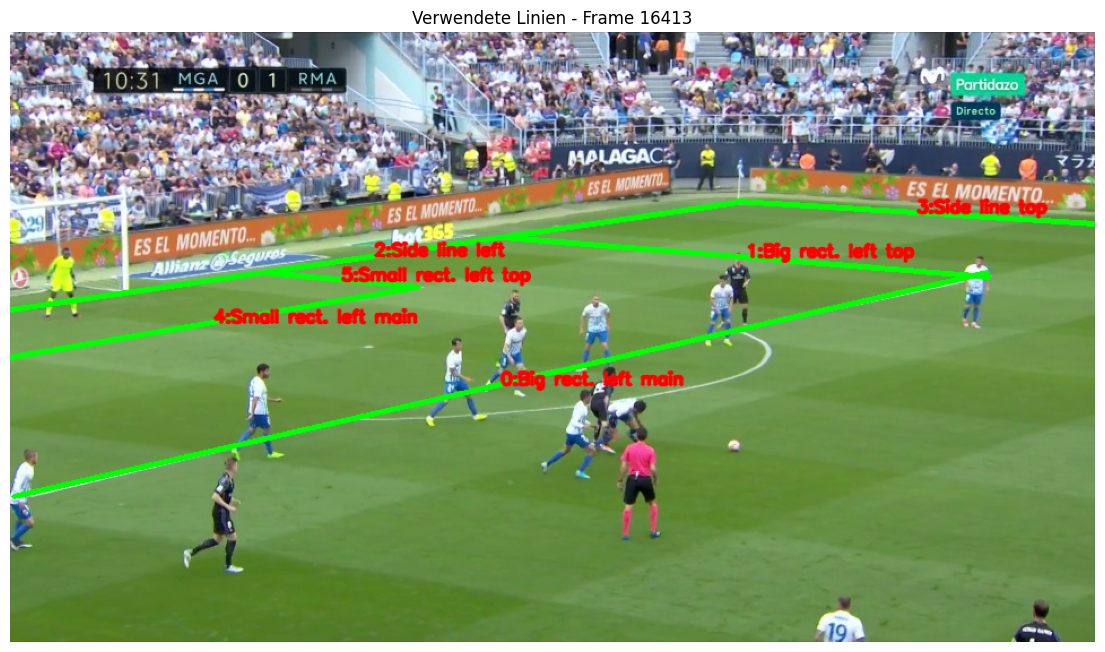

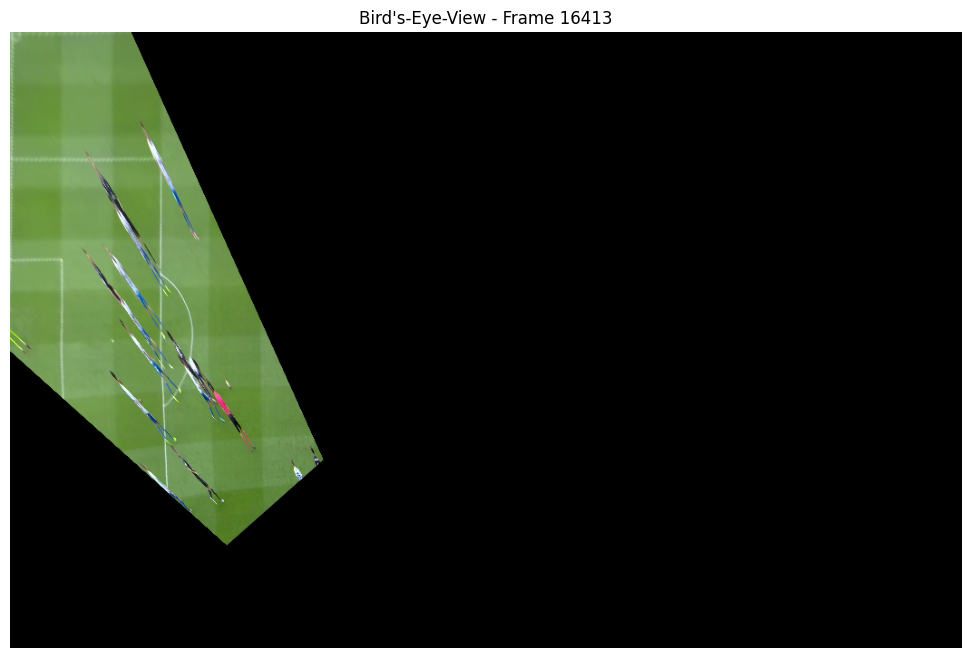

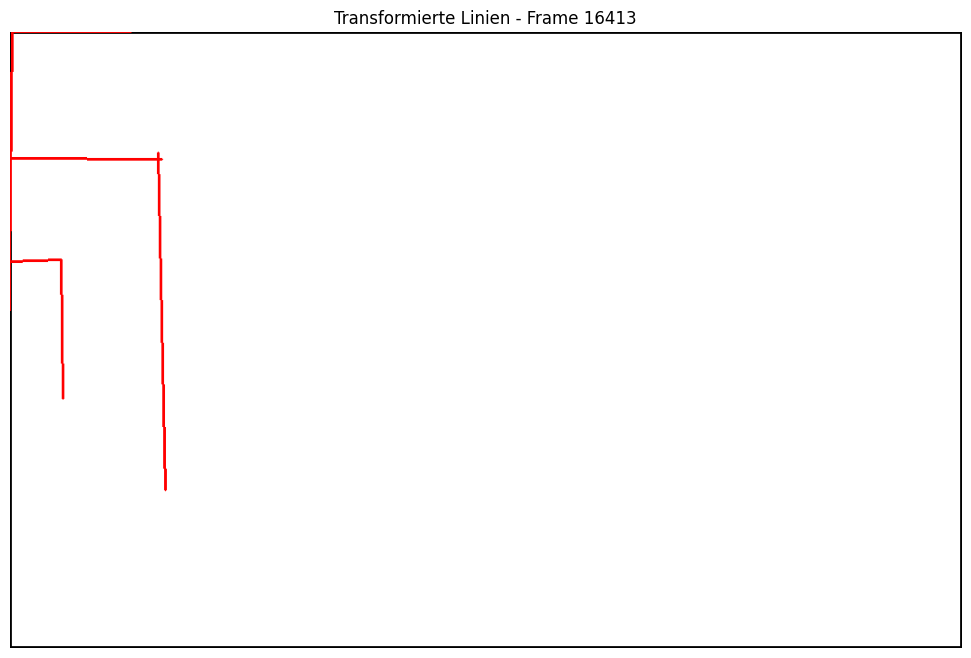


Frame 16414
Verwendete Linien: ['Big rect. right main', 'Big rect. right top', 'Side line right', 'Side line top', 'Small rect. right main', 'Small rect. right top']


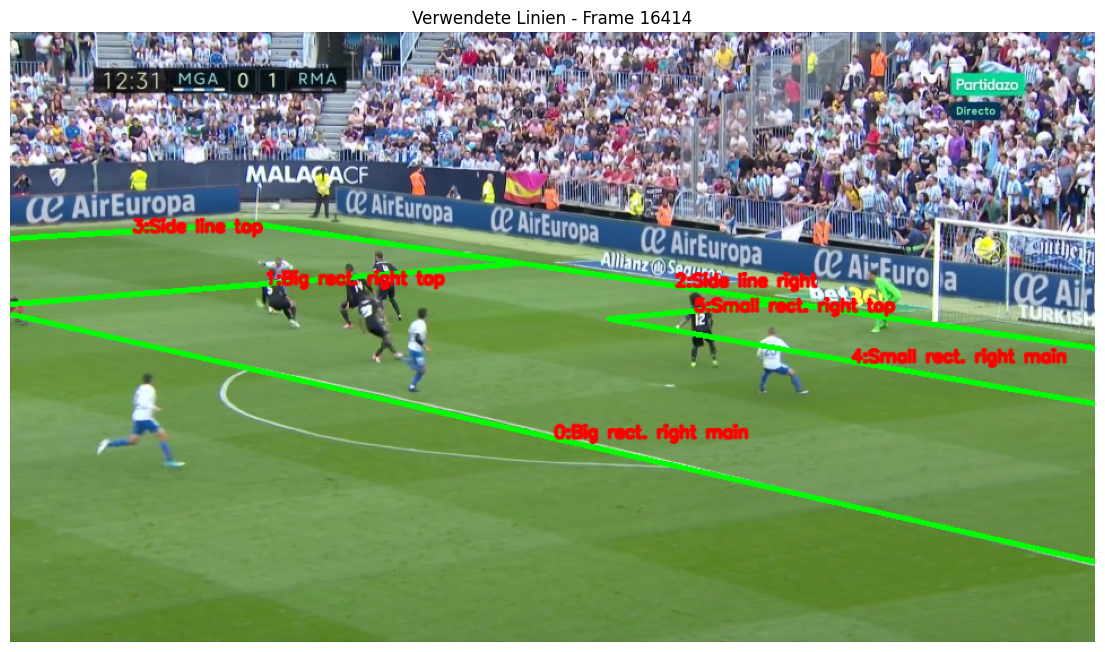

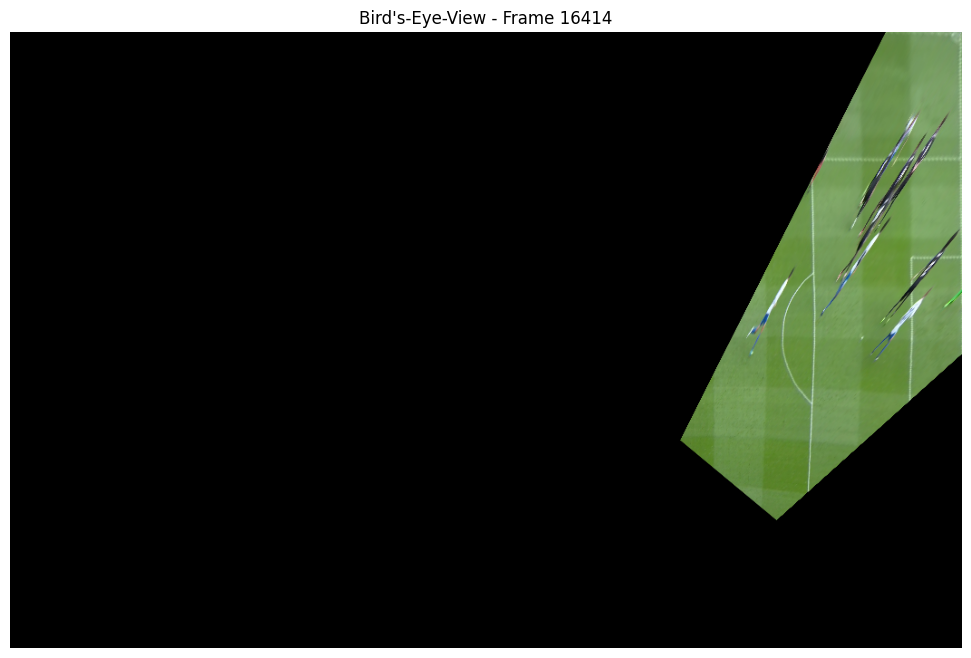

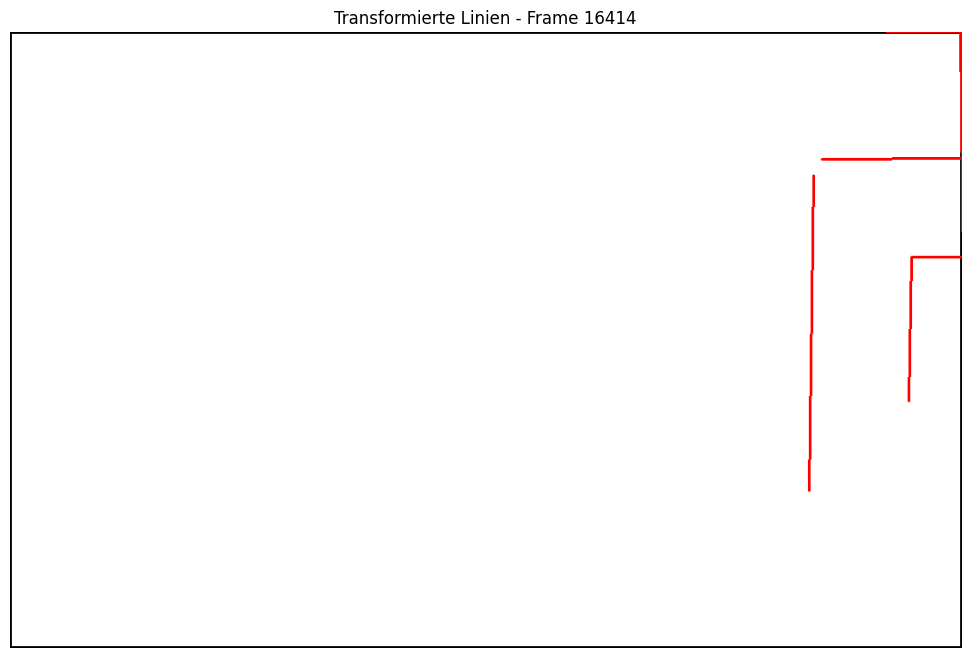


Frame 16415
Verwendete Linien: ['Big rect. right main', 'Big rect. right top', 'Side line right', 'Side line top', 'Small rect. right bottom', 'Small rect. right main', 'Small rect. right top']


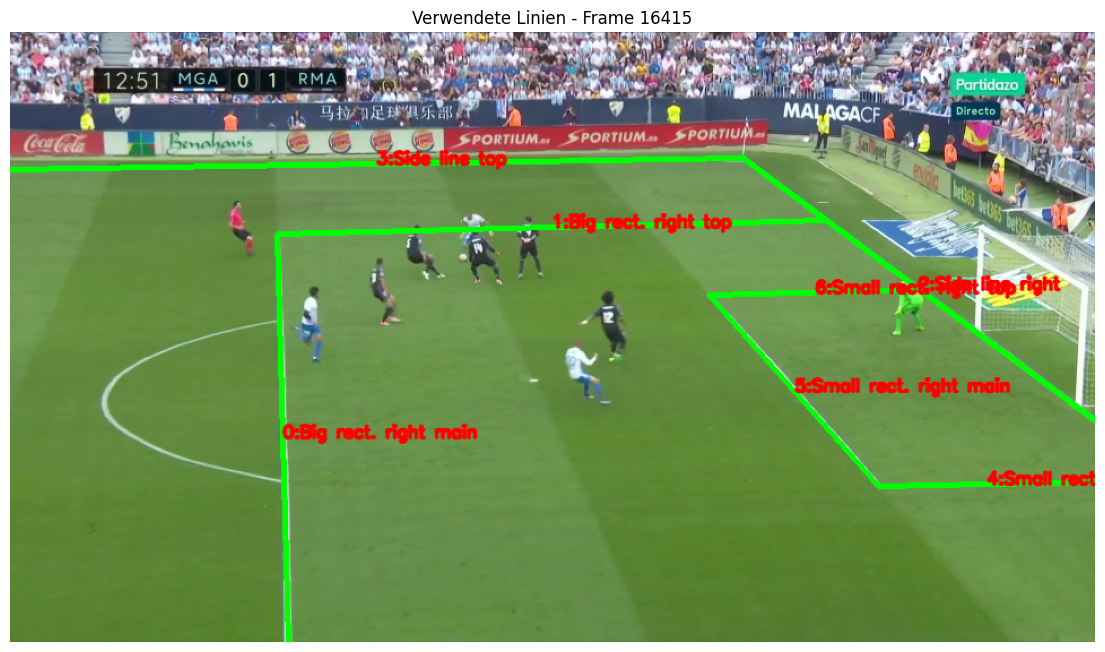

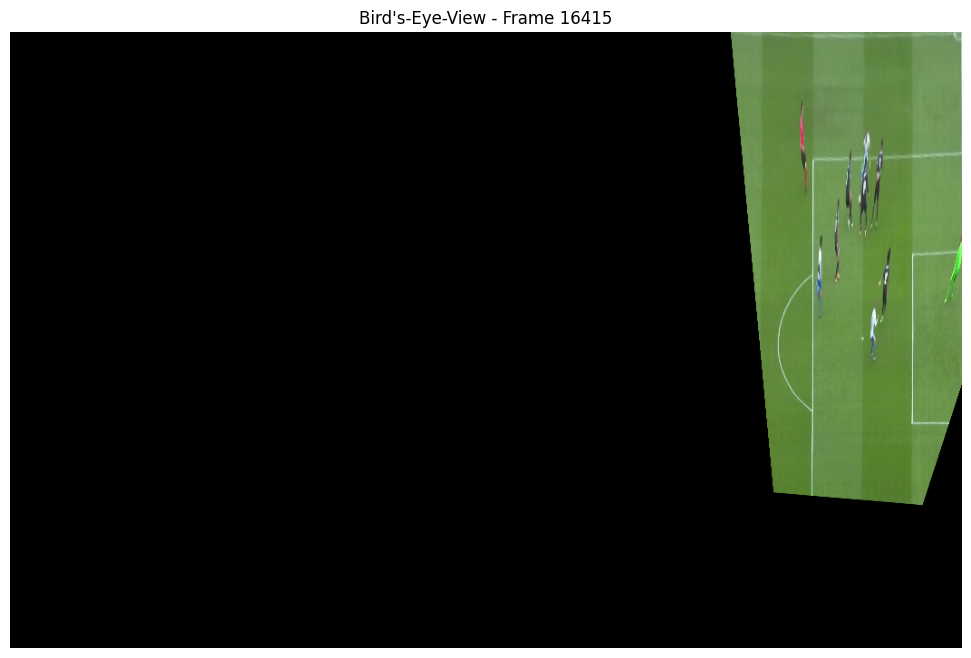

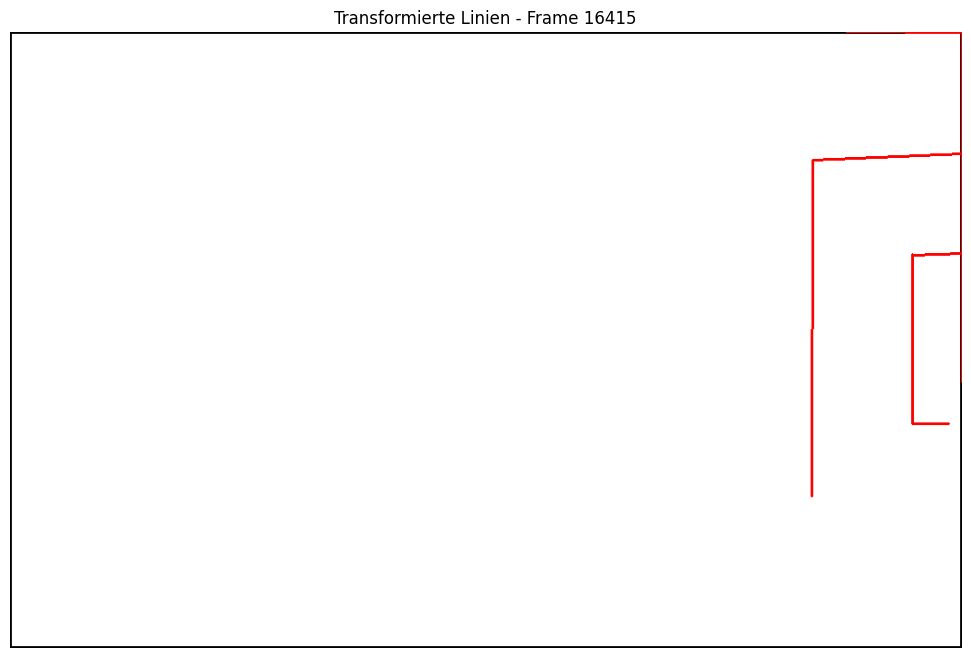


Frame 16416
Verwendete Linien: ['Big rect. left bottom', 'Big rect. left main', 'Big rect. left top', 'Side line left', 'Side line top', 'Small rect. left bottom', 'Small rect. left main', 'Small rect. left top']


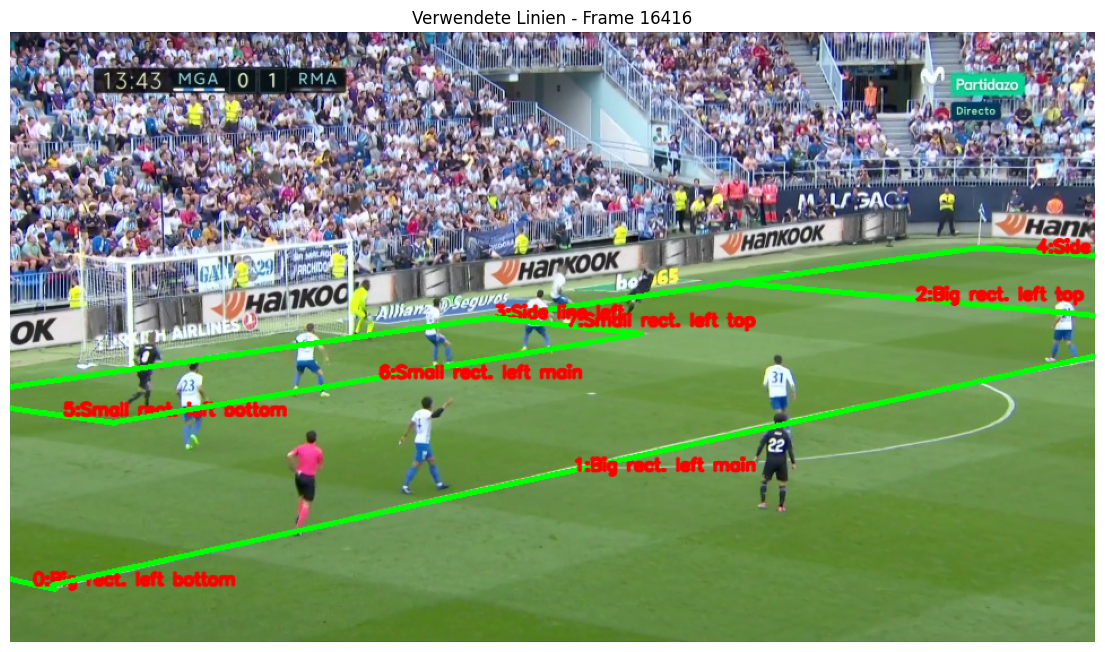

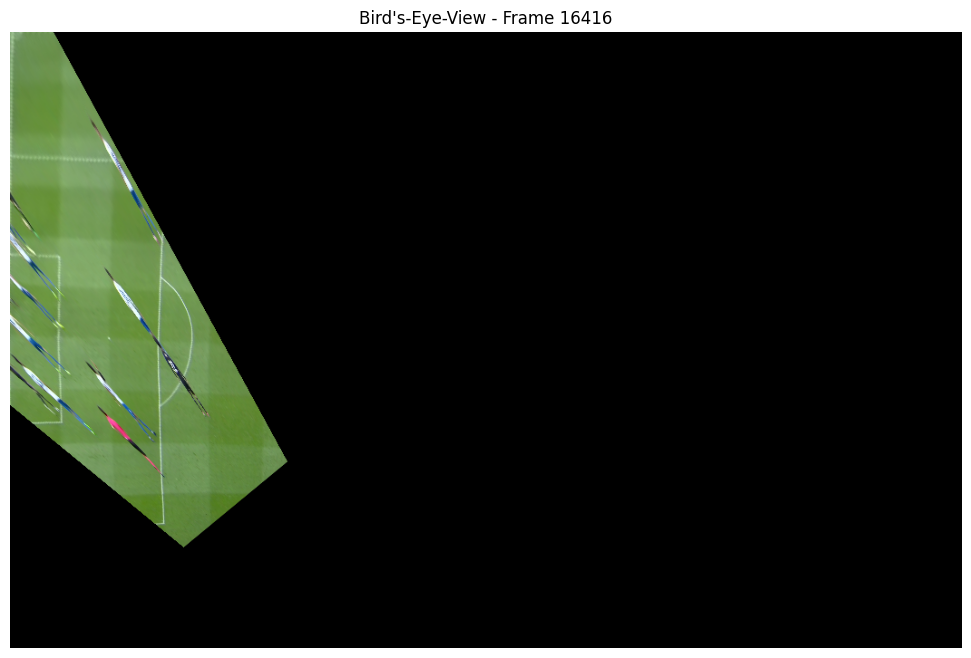

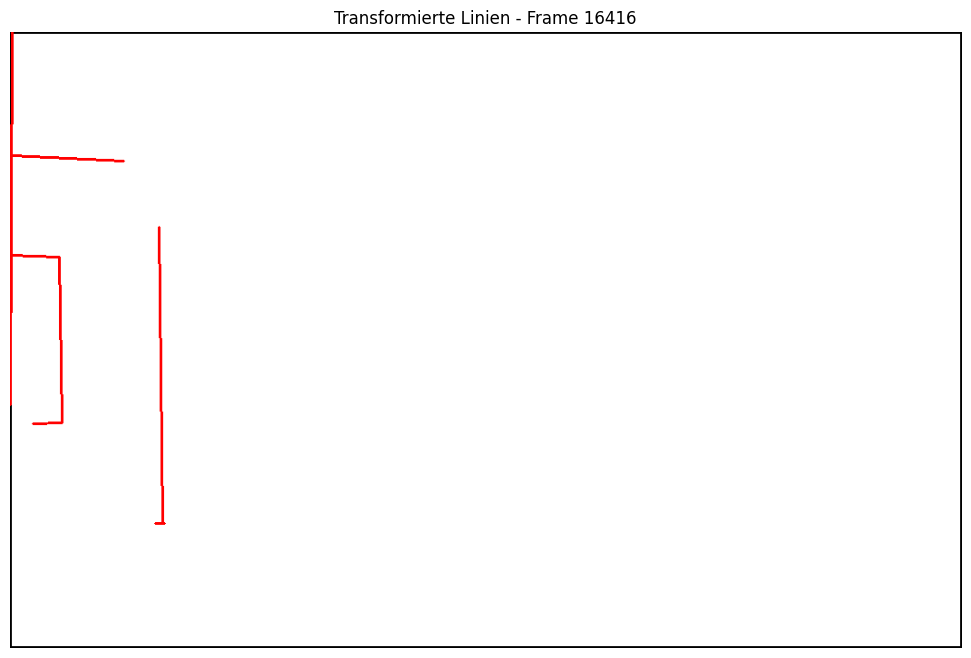


Frame 16417
Verwendete Linien: ['Big rect. left main', 'Big rect. left top', 'Side line left', 'Side line top', 'Small rect. left bottom', 'Small rect. left main', 'Small rect. left top']


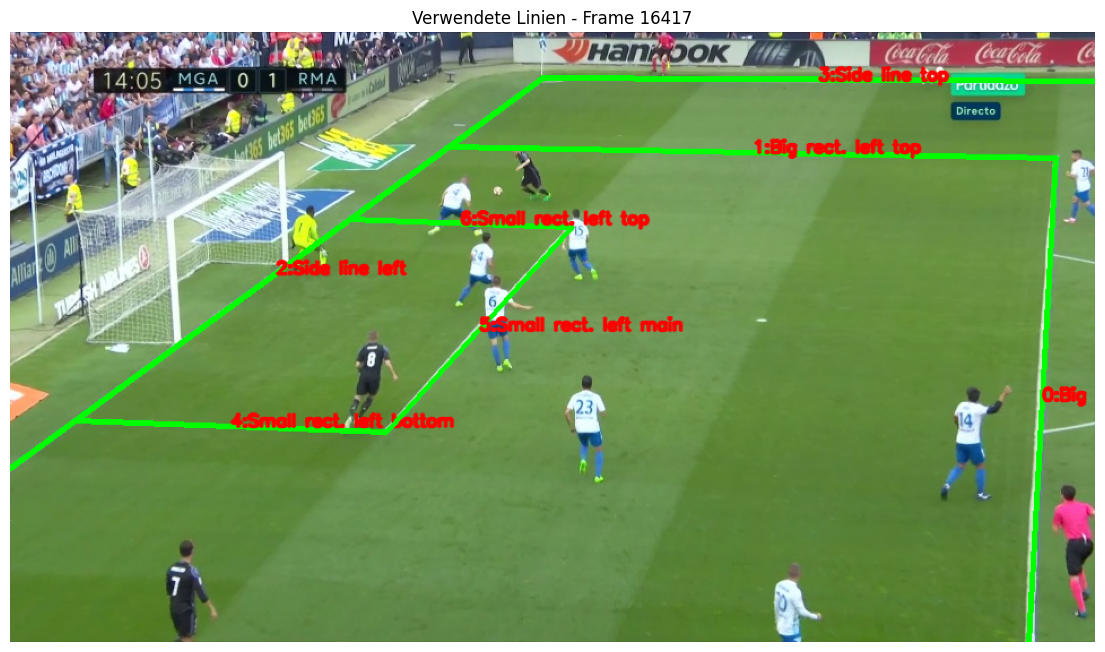

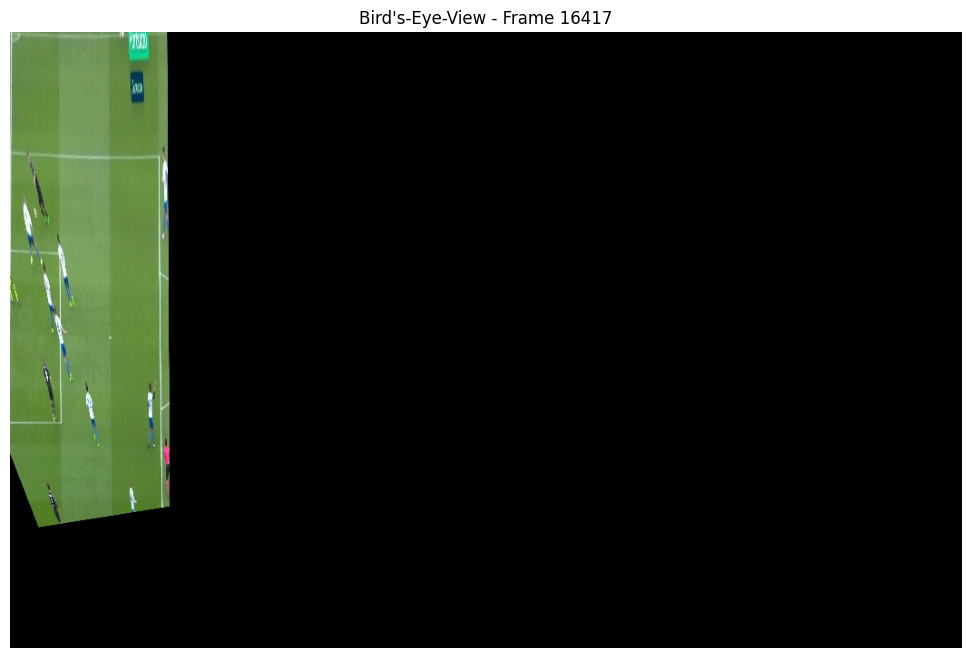

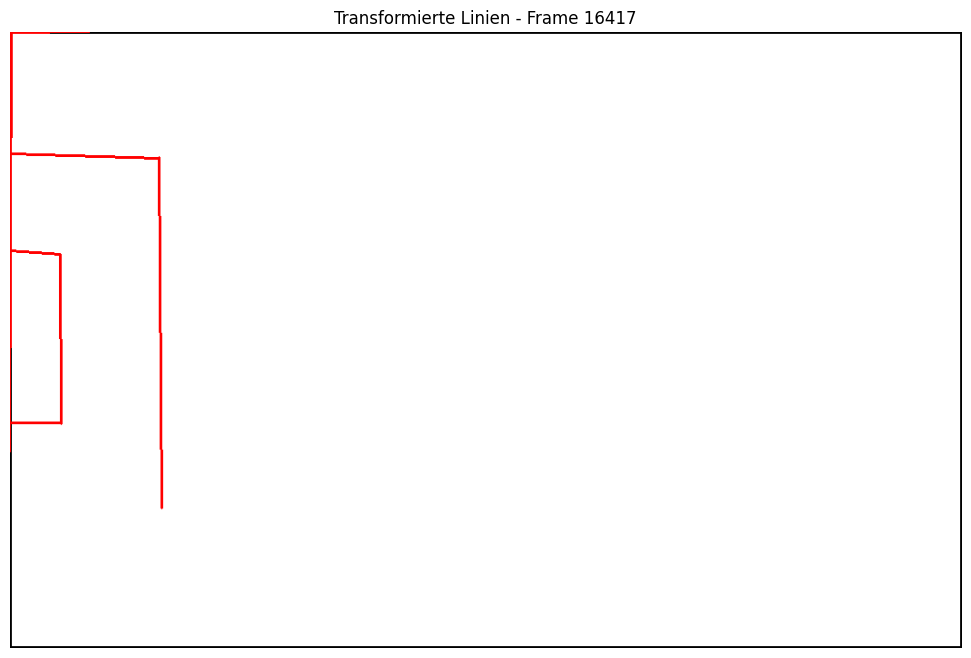

Berechnete Homographies:
775 -> 16413 OK
3775 -> 16414 OK
4275 -> 16415 OK
5575 -> 16416 OK
6125 -> 16417 OK


In [11]:
pitch = SoccerPitch(PITCH_LENGTH_M, PITCH_WIDTH_M)

results = {}

for frame_idx, calib_id in FRAME_TO_CALIB_ID.items():
    H_meter, H_scaled = calibrate_and_visualize_frame(
        frame_id=calib_id,
        base_path=CALIBRATION_BASE_PATH,
        pitch=pitch,
        scale=PITCH_SCALE
    )

    results[frame_idx] = {
        "calib_id": calib_id,
        "H_image_to_pitch": H_meter,
        "H_image_to_pitch_scaled": H_scaled,
    }

print("Berechnete Homographies:")
for k, v in results.items():
    print(k, "->", v["calib_id"], "OK" if v["H_image_to_pitch"] is not None else "FEHLER")

### Hilfsfunktion: nächstgelegene Homography für Tracking-Frame holen

In [12]:
def get_nearest_h(frame_idx: int, results_dict: dict):
    valid_keys = [
        k for k, v in results_dict.items()
        if v["H_image_to_pitch"] is not None
    ]

    if len(valid_keys) == 0:
        return None, None

    nearest_key = min(valid_keys, key=lambda k: abs(k - frame_idx))
    return results_dict[nearest_key]["H_image_to_pitch"], nearest_key

### Punkttrasnformations-Funktion

In [13]:
def apply_homography_to_point(H: np.ndarray, x: float, y: float):
    if H is None:
        return np.nan, np.nan

    p = np.array([x, y, 1.0], dtype=np.float64)
    q = H @ p

    if abs(q[2]) < 1e-12:
        return np.nan, np.nan

    q = q / q[2]
    return float(q[0]), float(q[1])

### Tracking-Daten auf den Pitch mappen

In [14]:
df_pitch = df.copy()

pitch_x_list = []
pitch_y_list = []
used_h_frame_list = []
used_calib_id_list = []
homography_frame_distance_list = []

for _, row in df_pitch.iterrows():
    if row["has_detection"] != 1 or pd.isna(row["foot_x"]) or pd.isna(row["foot_y"]):
        pitch_x_list.append(np.nan)
        pitch_y_list.append(np.nan)
        used_h_frame_list.append(None)
        used_calib_id_list.append(None)
        homography_frame_distance_list.append(np.nan)
        continue

    frame_idx = int(row["frame_idx"])
    H, used_h_frame = get_nearest_h(frame_idx, results)

    if H is None:
        pitch_x_list.append(np.nan)
        pitch_y_list.append(np.nan)
        used_h_frame_list.append(None)
        used_calib_id_list.append(None)
        homography_frame_distance_list.append(np.nan)
        continue

    px, py = apply_homography_to_point(H, float(row["foot_x"]), float(row["foot_y"]))

    pitch_x_list.append(px)
    pitch_y_list.append(py)
    used_h_frame_list.append(used_h_frame)
    used_calib_id_list.append(results[used_h_frame]["calib_id"])
    homography_frame_distance_list.append(abs(frame_idx - used_h_frame))

df_pitch["pitch_x_m"] = pitch_x_list
df_pitch["pitch_y_m"] = pitch_y_list
df_pitch["used_h_frame"] = used_h_frame_list
df_pitch["used_calib_id"] = used_calib_id_list
df_pitch["homography_frame_distance"] = homography_frame_distance_list

print(df_pitch.head(10))


   frame_idx  video_time_sec  track_id  class_id class_name  confidence  x1  \
0          0            0.00       NaN       NaN        NaN         NaN NaN   
1          1            0.04       NaN       NaN        NaN         NaN NaN   
2          2            0.08       NaN       NaN        NaN         NaN NaN   
3          3            0.12       NaN       NaN        NaN         NaN NaN   
4          4            0.16       NaN       NaN        NaN         NaN NaN   
5          5            0.20       NaN       NaN        NaN         NaN NaN   
6          6            0.24       NaN       NaN        NaN         NaN NaN   
7          7            0.28       NaN       NaN        NaN         NaN NaN   
8          8            0.32       NaN       NaN        NaN         NaN NaN   
9          9            0.36       NaN       NaN        NaN         NaN NaN   

   y1  x2  y2  ...  cy  foot_x  foot_y  orig_w  orig_h  has_detection  \
0 NaN NaN NaN  ... NaN     NaN     NaN    1280     720   

### Gültige Punkte filten

In [15]:
df_pitch_valid = df_pitch[
    (df_pitch["has_detection"] == 1) &
    (df_pitch["pitch_x_m"].notna()) &
    (df_pitch["pitch_y_m"].notna())
].copy()

print(f"Gültige Pitch-Punkte: {len(df_pitch_valid)}")
print(df_pitch_valid[[
    "frame_idx", "track_id", "foot_x", "foot_y", "pitch_x_m", "pitch_y_m", "used_calib_id"
]].head(10))

Gültige Pitch-Punkte: 2101
     frame_idx  track_id       foot_x      foot_y  pitch_x_m  pitch_y_m  \
168        168       NaN  1020.733002  383.702240  30.597146  35.692241   
426        426       NaN  1250.024414  491.808594  36.693579  41.566638   
427        427       2.0  1235.912842  493.178711  36.561060  41.796660   
428        428       2.0  1220.400269  491.358490  36.344123  41.834791   
433        433       2.0  1130.086609  483.067657  35.104674  42.213343   
434        434       2.0  1113.277405  479.808044  34.826365  42.173029   
435        435       2.0  1098.121216  475.845795  34.546157  42.068523   
437        437       2.0  1067.946167  469.325806  34.012268  41.948059   
438        438       2.0  1052.424744  466.933624  33.758746  41.950087   
439        439       2.0  1035.381439  464.870728  33.493347  41.990679   

    used_calib_id  
168         16413  
426         16413  
427         16413  
428         16413  
433         16413  
434         16413  
435    

In [16]:
df_pitch_valid["inside_pitch"] = (
    (df_pitch_valid["pitch_x_m"] >= 0.0) &
    (df_pitch_valid["pitch_x_m"] <= PITCH_LENGTH_M) &
    (df_pitch_valid["pitch_y_m"] >= 0.0) &
    (df_pitch_valid["pitch_y_m"] <= PITCH_WIDTH_M)
)

inside_ratio = df_pitch_valid["inside_pitch"].mean() if len(df_pitch_valid) > 0 else np.nan
print(f"Anteil Punkte innerhalb des Feldes: {inside_ratio:.3f}")

Anteil Punkte innerhalb des Feldes: 0.902


### Alle Punkte auf dem Pitch visualisieren

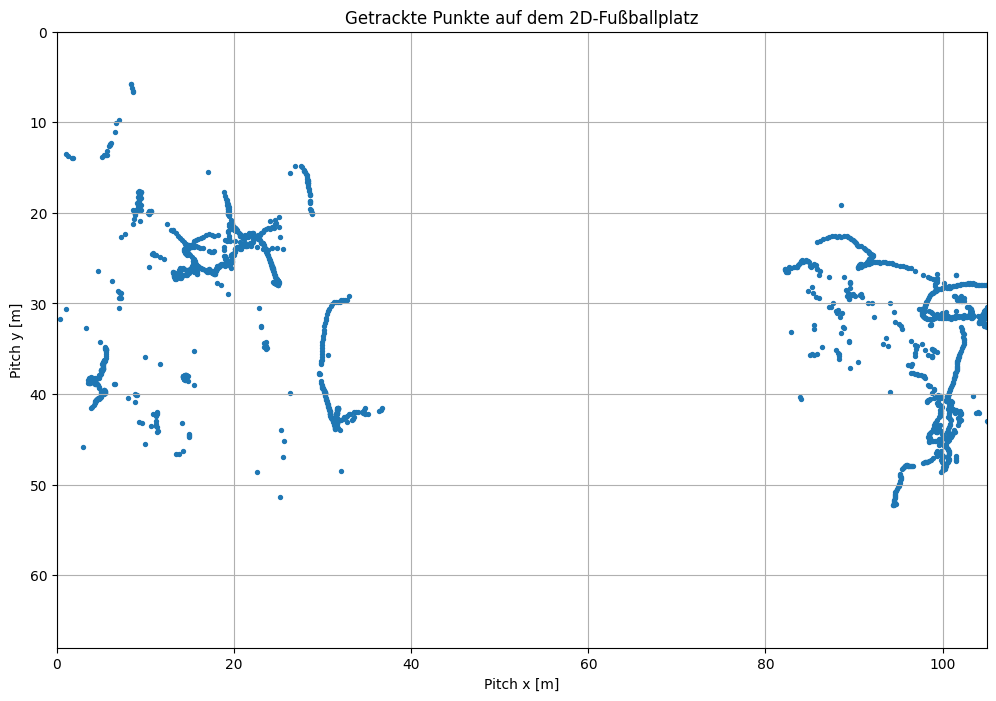

In [17]:
plt.figure(figsize=(12, 8))
plt.scatter(df_pitch_valid["pitch_x_m"], df_pitch_valid["pitch_y_m"], s=8)
plt.xlim(0, PITCH_LENGTH_M)
plt.ylim(PITCH_WIDTH_M, 0)
plt.xlabel("Pitch x [m]")
plt.ylabel("Pitch y [m]")
plt.title("Getrackte Punkte auf dem 2D-Fußballplatz")
plt.grid(True)
plt.show()

### Beste Detection pro Frame als Trajektorie plotten

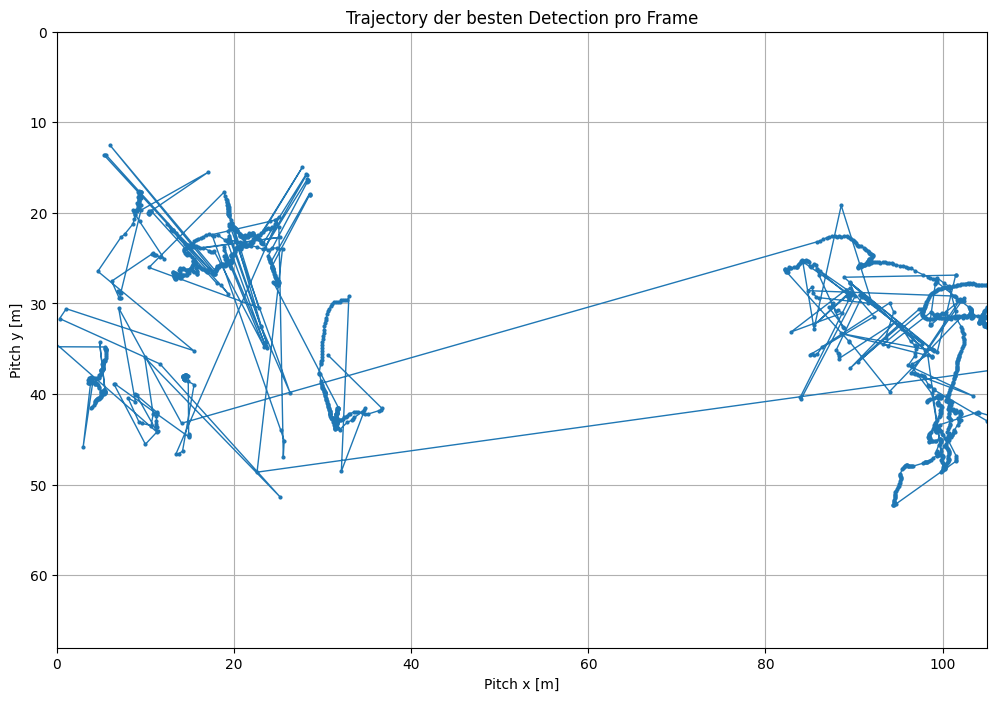

In [18]:
df_best_per_frame_pitch = (
    df_pitch_valid.sort_values(["frame_idx", "confidence"], ascending=[True, False])
    .groupby("frame_idx", as_index=False)
    .first()
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 8))
plt.plot(
    df_best_per_frame_pitch["pitch_x_m"],
    df_best_per_frame_pitch["pitch_y_m"],
    marker="o",
    markersize=2,
    linewidth=1
)
plt.xlim(0, PITCH_LENGTH_M)
plt.ylim(PITCH_WIDTH_M, 0)
plt.xlabel("Pitch x [m]")
plt.ylabel("Pitch y [m]")
plt.title("Trajectory der besten Detection pro Frame")
plt.grid(True)
plt.show()

### Ergebnisse speichern

In [19]:
df_pitch.to_csv(PITCH_CSV_PATH, index=False)

parquet_written = False
parquet_error = None
try:
    df_pitch.to_parquet(PITCH_PARQUET_PATH, index=False)
    parquet_written = True
except ImportError as exc:
    parquet_error = str(exc)
    print("Parquet wurde übersprungen: pyarrow oder fastparquet ist nicht installiert.")

inside_count = int(df_pitch_valid["inside_pitch"].sum()) if "inside_pitch" in df_pitch_valid else None
homography_distance = df_pitch_valid["homography_frame_distance"].dropna()

pitch_metadata = {
    "frame_to_calib_id": FRAME_TO_CALIB_ID,
    "pitch_length_m": PITCH_LENGTH_M,
    "pitch_width_m": PITCH_WIDTH_M,
    "num_tracking_rows": int(len(df)),
    "num_valid_pitch_rows": int(len(df_pitch_valid)),
    "num_inside_pitch_rows": inside_count,
    "inside_pitch_ratio": None if pd.isna(inside_ratio) else float(inside_ratio),
    "homography_frame_distance_median": None if homography_distance.empty else float(homography_distance.median()),
    "homography_frame_distance_max": None if homography_distance.empty else int(homography_distance.max()),
    "output_csv": str(PITCH_CSV_PATH),
    "output_parquet": str(PITCH_PARQUET_PATH) if parquet_written else None,
    "parquet_written": parquet_written,
    "parquet_error": parquet_error,
}

with open(PITCH_META_PATH, "w", encoding="utf-8") as f:
    json.dump(pitch_metadata, f, indent=2, ensure_ascii=False)

print(f"Pitch CSV gespeichert: {PITCH_CSV_PATH}")
if parquet_written:
    print(f"Pitch Parquet gespeichert: {PITCH_PARQUET_PATH}")
print(f"Pitch Metadaten gespeichert: {PITCH_META_PATH}")


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.